# Hess Corporation: A Comprehensive Valuation & M&A Analysis
## In the Context of Chevron's $53B Acquisition

*An investment banking analysis combining trading comps, precedent transactions, DCF, LBO, and accretion/dilution methodologies — built with live market data.*

---

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from dotenv import load_dotenv

load_dotenv()

from config.constants import (HESS_FINANCIALS, HESS_UNAFFECTED_PRICE, DEAL_TERMS,
    CVX_FINANCIALS, PRECEDENT_TRANSACTIONS, PEER_TICKERS, HESS_PRODUCTION_HISTORY,
    DAMODARAN_EP, SYNERGY_SCENARIOS, PEER_PRODUCTION_KBOEPD)
from utils.styling import (setup_ib_style, IB_COLORS, plot_football_field,
    plot_sensitivity_heatmap, plot_waterfall, plot_tornado, plot_monte_carlo_hist,
    plot_comps_scatter, plot_bar_chart, plot_grouped_bar, plot_area_chart,
    plot_oil_price_chart, format_comps_table)
from utils.data_fetch import fetch_peer_comps, fetch_commodity_prices, fetch_fred_data, validate_tickers

setup_ib_style()
np.random.seed(42)

print("✓ All imports loaded successfully")

✓ All imports loaded successfully


In [2]:
# Validate and fetch peer data
valid_tickers, failed_tickers = validate_tickers(PEER_TICKERS)
print(f"✓ {len(valid_tickers)}/{len(PEER_TICKERS)} peers available")
if failed_tickers:
    print(f"  Skipped: {failed_tickers}")

peer_data = fetch_peer_comps(valid_tickers)
commodities = fetch_commodity_prices()
fred_data = fetch_fred_data(os.getenv('FRED_API_KEY'))

print(f"✓ Commodities: {list(commodities.keys())}")
print(f"✓ FRED series: {list(fred_data.keys())}")

✓ 10/10 peers available


[fetch_peer_comps] Fetched 10/10 peers


[fetch_commodity_prices] Fetched: WTI, Brent, NatGas, Treasury_10Y, XLE, XOP, SP500


[fetch_fred_data] Fetched series: BAMLH0A0HYM2, DHHNGSP, DFF, T10Y2Y
✓ Commodities: ['WTI', 'Brent', 'NatGas', 'Treasury_10Y', 'XLE', 'XOP', 'SP500']
✓ FRED series: ['BAMLH0A0HYM2', 'DHHNGSP', 'DFF', 'T10Y2Y']


---

## 1. Executive Summary

On **October 23, 2023**, Chevron Corporation (CVX) announced an all-stock acquisition of Hess Corporation for approximately **$53 billion** in equity value (~$60B enterprise value), offering **1.025 CVX shares per HES share** — implying a price of ~$171/share and a **~10% premium** to Hess's unaffected closing price of $155.39.

**Key Deal Highlights:**
- **Strategic rationale:** Chevron gains Hess's 30% interest in Guyana's Stabroek Block — one of the largest oil discoveries in the past decade with ~11 billion BOE of recoverable resources
- **Structure:** All-stock merger, no cash component
- **Regulatory path:** FTC clearance obtained; deal closed October 1, 2024
- **Key risk:** ExxonMobil's preemptive rights claim over Hess's Guyana interest, resolved via ICC arbitration in September 2024 in favor of Chevron/Hess

### Valuation Summary

The table and football field chart below synthesize our findings across five valuation methodologies:

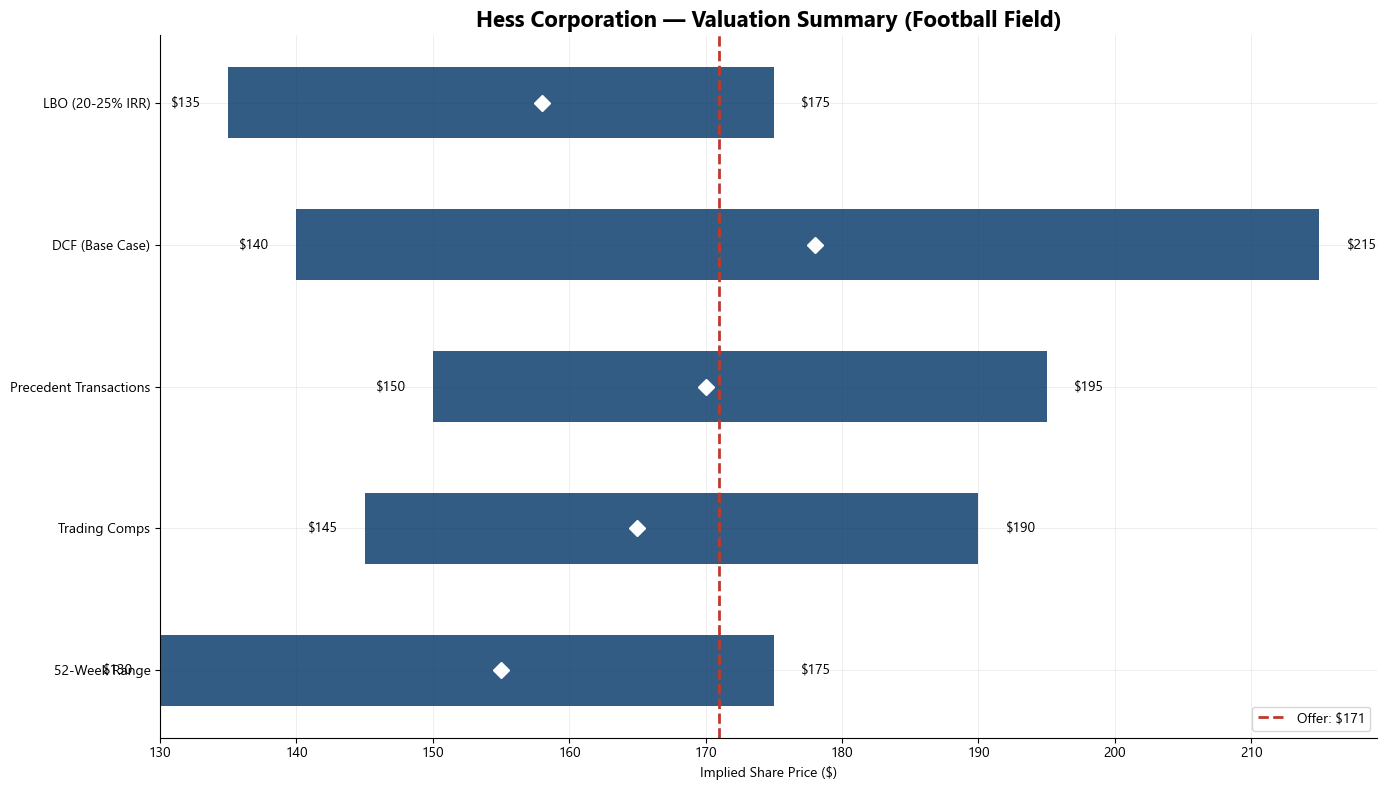

In [3]:
# PLACEHOLDER — Updated in Section 8 after all analyses are computed
placeholder_valuations = {
    '52-Week Range': (130, 155, 175),
    'Trading Comps': (145, 165, 190),
    'Precedent Transactions': (150, 170, 195),
    'DCF (Base Case)': (140, 178, 215),
    'LBO (20-25% IRR)': (135, 158, 175),
}

fig = plot_football_field(placeholder_valuations, DEAL_TERMS['implied_price'],
                          'Hess Corporation — Valuation Summary (Football Field)')
plt.show()

> **Note:** The football field chart above is a preliminary summary. Each methodology is detailed in subsequent sections. The final comprehensive football field appears in Section 8.

---

## 2. Company & Industry Overview

### What We're Doing
Providing context on Hess Corporation, its key assets, and the energy sector dynamics that drove this deal.

### Hess Corporation Profile

Hess Corporation (NYSE: HES, now delisted) was a global exploration and production (E&P) company headquartered in New York City. Founded in 1933 by Leon Hess, the company operated primarily as an upstream oil and gas producer with assets spanning:

- **Guyana (Stabroek Block):** 30% working interest (operator: ExxonMobil). The crown jewel — one of the largest offshore oil discoveries in the past decade with estimated recoverable resources of ~11 billion BOE. Production ramped from zero in late 2019 to ~640 KBOEPD gross by 2027 (Hess net: ~195 KBOEPD in 2023).
- **Bakken (North Dakota):** ~170,000 net acres in the Williston Basin, producing ~190 KBOEPD
- **Gulf of Mexico:** Deepwater assets with ~35 KBOEPD
- **Southeast Asia (Malaysia/JDA):** ~30 KBOEPD of natural gas production

### Why Chevron Wants Hess

The Stabroek Block is the strategic prize. Guyana offers:
- **Low-cost barrels:** ~$35/bbl breakeven — among the lowest globally
- **Decades of production growth:** Multiple FPSOs planned, with production expected to exceed 1.2M BOEPD gross by 2030
- **Portfolio diversification:** Reduces Chevron's Permian concentration
- **Resource optionality:** Continued exploration upside in the 6.6 million acre block


### The Guyana Stabroek Block — Why It Matters

The Stabroek Block has transformed Hess from a mid-cap E&P into a strategic acquisition target. Key facts:

| Metric | Value |
|--------|-------|
| Block size | 6.6 million acres |
| Operator | ExxonMobil (45% WI) |
| Hess interest | 30% working interest |
| CNOOC interest | 25% working interest |
| Discovered resources | ~11 billion BOE |
| Current FPSOs | 3 (Liza Phase 1, Liza Phase 2, Payara) |
| Planned FPSOs | 6+ total by 2030 |
| Gross production (2024) | ~640 KBOEPD |
| Breakeven cost | ~$35/bbl |

The block's significance cannot be overstated: it represents the largest discovery of conventional oil resources in the past decade and one of the lowest-cost producing basins globally. For Chevron, acquiring Hess's 30% stake provides exposure to this growth without the operational burden of being the operator.

### The Exxon Arbitration Risk

ExxonMobil, as operator of the Stabroek Block, claimed a right of first refusal over Hess's interest, arguing that the Chevron merger effectively constituted a "change of control" that triggered preemptive rights under the joint operating agreement. This claim was heard by an ICC arbitration tribunal, which ruled in **September 2024 in favor of Chevron/Hess**, clearing the final major obstacle to deal completion.


### Energy Sector Context: The E&P Consolidation Wave

The Chevron/Hess deal did not happen in isolation. 2023-2024 saw the largest wave of E&P M&A activity since the early 2000s, driven by:

1. **Capital discipline era:** Post-2020 crash, E&P companies prioritized returns over growth — creating cash-rich balance sheets
2. **Inventory concerns:** Permian Basin tier-1 drilling inventory declining, pushing companies to acquire rather than explore
3. **Shareholder pressure:** Investors rewarded scale, diversification, and operational efficiency
4. **Favorable commodity prices:** WTI sustained above $70/bbl provided deal economics

Over $200 billion in E&P deals were announced in 2023-2024, including ExxonMobil/Pioneer ($64.5B), ConocoPhillips/Marathon Oil ($22.5B), and Diamondback/Endeavor ($26B).

### Key Assumptions
- Hess production figures from 10-K filings (FY2022-2023)
- Guyana resource estimates from operator (ExxonMobil) public disclosures
- Commodity prices from Yahoo Finance (front-month futures, not spot)

### Limitations
- Production forecasts beyond 2024 are estimates and subject to operational/regulatory risk
- Guyana resource estimates may change with further exploration/appraisal


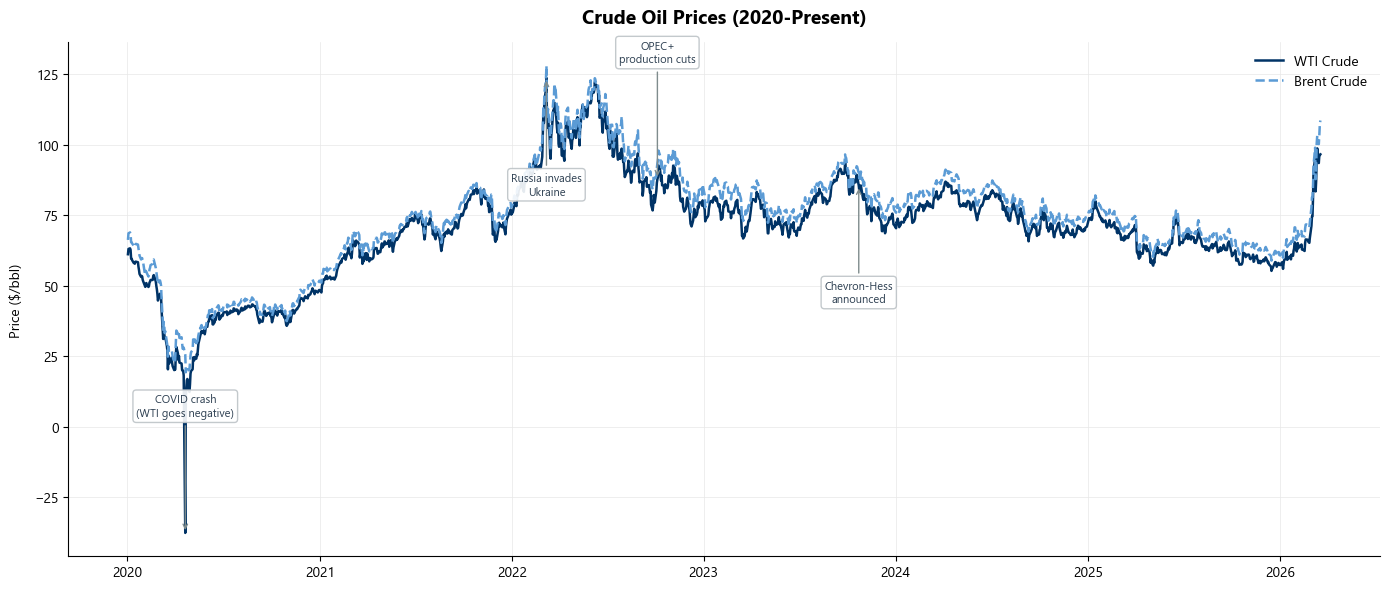

In [4]:
# Oil Price History (2020-Present) with Key Events
wti_df = commodities.get('WTI')
brent_df = commodities.get('Brent')

def _to_series(df):
    if df is None:
        return None
    if hasattr(df, 'columns'):
        # Handle MultiIndex columns from newer yfinance
        if isinstance(df.columns, pd.MultiIndex):
            close_cols = [c for c in df.columns if 'Close' in str(c)]
            s = df[close_cols[0]] if close_cols else df.iloc[:, 0]
        elif 'Close' in df.columns:
            s = df['Close']
        else:
            s = df.iloc[:, 0]
        return s.squeeze().dropna()
    return df.dropna()

wti = _to_series(wti_df)
brent = _to_series(brent_df)

if wti is not None and brent is not None:
    events = {
        '2020-04-20': 'COVID crash\n(WTI goes negative)',
        '2022-03-08': 'Russia invades\nUkraine',
        '2022-10-05': 'OPEC+\nproduction cuts',
        '2023-10-23': 'Chevron-Hess\nannounced',
    }
    fig = plot_oil_price_chart(wti, brent, events,
                               'Crude Oil Prices (2020-Present)')
    plt.show()
else:
    print('\u26a0 Oil price data unavailable')


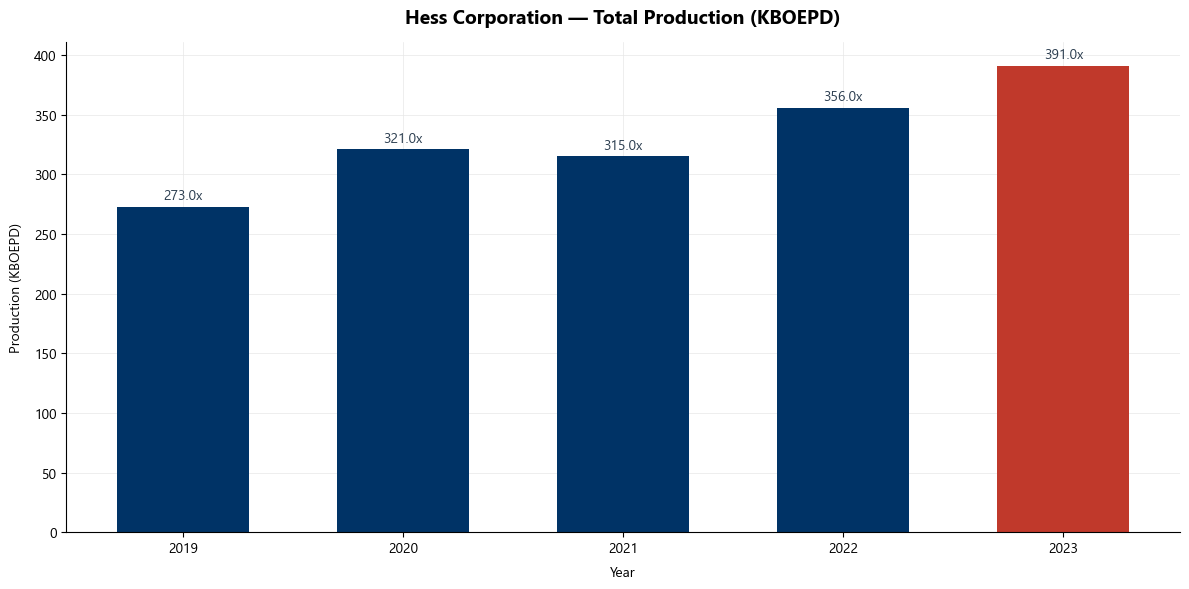

In [5]:
# Hess Production Growth (2019-2023)
years = list(HESS_PRODUCTION_HISTORY.keys())
production = list(HESS_PRODUCTION_HISTORY.values())

fig = plot_bar_chart(
    labels=[str(y) for y in years],
    values=production,
    title='Hess Corporation — Total Production (KBOEPD)',
    xlabel='Year',
    ylabel='Production (KBOEPD)',
    highlight_idx=len(years)-1  # Highlight most recent year
)
plt.show()


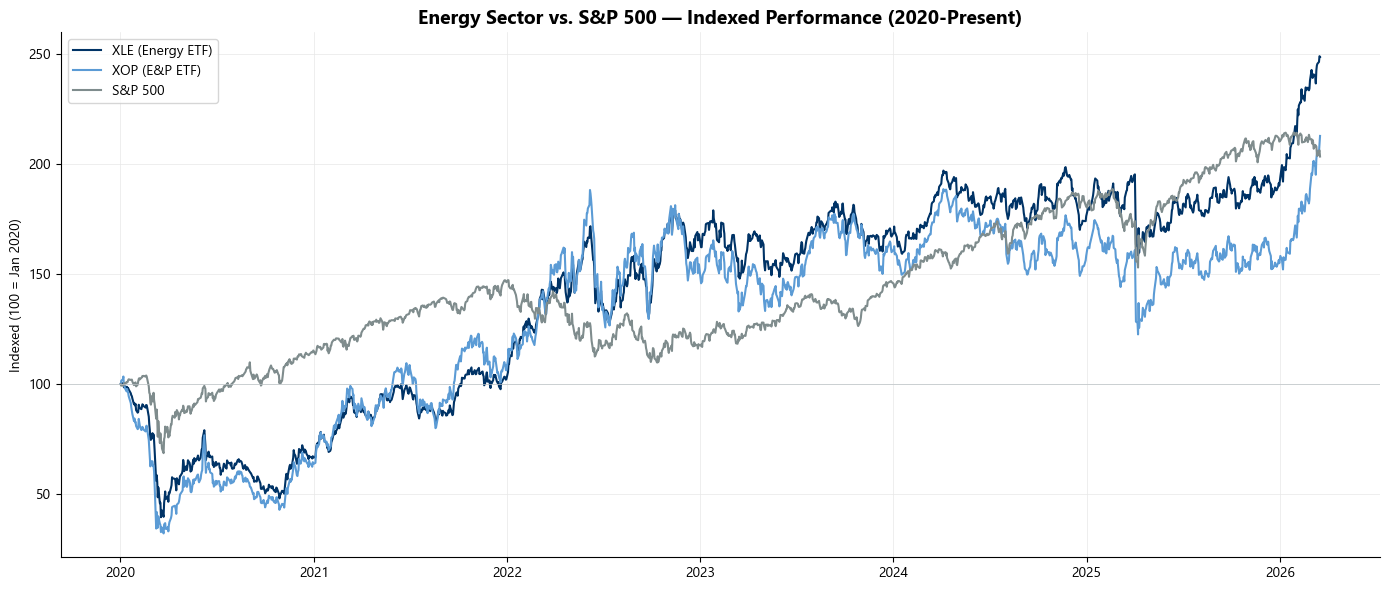

In [6]:
# E&P Sector Performance vs S&P 500 (Normalized to 100)
xle = commodities.get('XLE')
xop = commodities.get('XOP')
sp500 = commodities.get('SP500')

if xle is not None and xop is not None and sp500 is not None:
    fig, ax = plt.subplots(figsize=(14, 6))

    # Normalize to 100 at start date
    for series, name, color in [(xle, 'XLE (Energy ETF)', IB_COLORS['navy']),
                                 (xop, 'XOP (E&P ETF)', IB_COLORS['steel_blue']),
                                 (sp500, 'S&P 500', IB_COLORS['gray'])]:
        # Handle both single and multi-level columns from yfinance
        if hasattr(series, 'columns'):
            if 'Close' in series.columns:
                prices = series['Close']
            else:
                prices = series.iloc[:, 0]
        else:
            prices = series
        normalized = (prices / prices.iloc[0]) * 100
        ax.plot(normalized.index, normalized.values, label=name, color=color, linewidth=1.5)

    ax.axhline(100, color=IB_COLORS['light_gray'], linestyle='-', linewidth=0.5)
    ax.set_title('Energy Sector vs. S&P 500 — Indexed Performance (2020-Present)',
                 fontsize=14, fontweight='bold')
    ax.set_ylabel('Indexed (100 = Jan 2020)')
    ax.legend(loc='upper left')
    ax.set_xlabel('')
    plt.tight_layout()
    plt.show()
else:
    print("\u26a0 ETF/index data unavailable")


### So What

The charts above illustrate two key dynamics:

1. **Energy has outperformed:** After the 2020 COVID crash, the energy sector massively outperformed the broader market (2022-2023), driven by supply constraints, OPEC+ discipline, and Russia-Ukraine supply disruption. This created the war chests that funded the M&A wave.

2. **Hess's production story is Guyana:** The 43% production growth from 2019 to 2023 (273 → 391 KBOEPD) is almost entirely driven by the Stabroek Block ramp. This trajectory — and the 2030+ growth runway — is what Chevron is paying for.

---
